In [1]:
import matplotlib.pyplot as plt
import win32com.client
import math

In [2]:
# Launch UniSim
unisim_app = win32com.client.Dispatch("UniSimDesign.Application")
unisim_app.Visible = True

# Open the simulation file
case = unisim_app.SimulationCases.Open(r"C:\Users\sahm\Downloads\1_Sugg\1.usc")

# Access the main flowsheet
main_flowsheet = case.Flowsheet

# Print all available attributes and methods of the flowsheet
#print(dir(main_flowsheet))

In [3]:
# List all subflowsheets using the Flowsheets collection

print("Subflowsheets found in 'Flowsheets':")
for i in range(main_flowsheet.Flowsheets.Count):
    sub = main_flowsheet.Flowsheets.Item(i)
    print(f"{i}: {sub.Name}")

Subflowsheets found in 'Flowsheets':
0: TPL14
1: TPL16
2: TPL17
3: TPL13
4: TPL19
5: TPL15
6: TPL21
7: TPL22
8: TPL24
9: TPL25
10: TPL26
11: TPL27
12: TPL28
13: TPL29
14: TPL18
15: TPL1
16: TPL3


In [4]:
tpl18 = main_flowsheet.Flowsheets.Item("TPL18")

print("Operations in TPL18:")
for i in range(tpl18.Operations.Count):
    op = tpl18.Operations.Item(i)
    print(f"{i}: {op.Name}")

Operations in TPL18:
0: MIX-26-06-01
1: 26HJ701
2: 26VG701
3: T-KA701
4: RCY-6
5: 26FV7019
6: 26LV7018
7: 26KA750
8: 26VG701 check
9: 26KA750 - Surge control


In [5]:
compressor = tpl18.Operations.Item("26KA750")
#print(dir(compressor))

In [6]:
print("Using performance curves:", compressor.UsingCurves)

Using performance curves: 1


In [7]:
# Access the first (and only) curve

curve_data = compressor.Curves.Item(0)
print(dir(curve_data))


['ActivateCurve', 'AddRef', 'Application', 'CreateUserVariable', 'DeleteAllData', 'Efficiency', 'EfficiencyValue', 'FlowUnits', 'GasFlowRate', 'GasFlowRateValue', 'GetIDsOfNames', 'GetTypeInfo', 'GetTypeInfoCount', 'GetUserVariable', 'Head', 'HeadUnits', 'HeadValue', 'Invoke', 'IsValid', 'Moniker', 'OpenStorage', 'Parent', 'QueryInterface', 'Release', 'Speed', 'SpeedValue', 'TaggedName', 'TypeName', 'UniqueID', 'VisibleTypeName', '_ApplyTypes_', '_FlagAsMethod', '_LazyAddAttr_', '_NewEnum', '_Release_', '_UpdateWithITypeInfo_', '__AttrToID__', '__LazyMap__', '__bool__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__',

In [8]:

for i in range(compressor.Curves.Count-6,compressor.Curves.Count):
    av_prop = compressor.Curves.Item(i)
    print(f"{i}: {av_prop.Name}")
    

18: 6503 LWP -case 106 (LP)
19: 6503 LWP case 103
20: 7432 LWP case 103
21: 8361 LWP case 103
22: 9290 LWP case 103
23: 9755 LWP case 103


In [25]:
curve = compressor.Curves.Item(19)

print("Speed:", curve.SpeedValue)
print("Flow:", curve.GasFlowRateValue)
print("Head:", curve.HeadValue)
print("Efficiency:", curve.EfficiencyValue)
print("------------------------------------")
print("Head value:", curve.HeadValue)
print("Flow value:", curve.GasFlowRateValue)

Speed: 108.38333333333334
Flow: (2.2035258236111113, 2.533305198611111, 3.1666314972222223, 3.732502925)
Head: (8017.929900628656, 7762.0871225138035, 6930.598096189831, 5651.384208674725)
Efficiency: (83.87931034, 85.1814882, 84.54627949, 78.9246824)
------------------------------------
Head value: (8017.929900628656, 7762.0871225138035, 6930.598096189831, 5651.384208674725)
Flow value: (2.2035258236111113, 2.533305198611111, 3.1666314972222223, 3.732502925)


In [35]:
curve.

TypeError: 'tuple' object is not callable

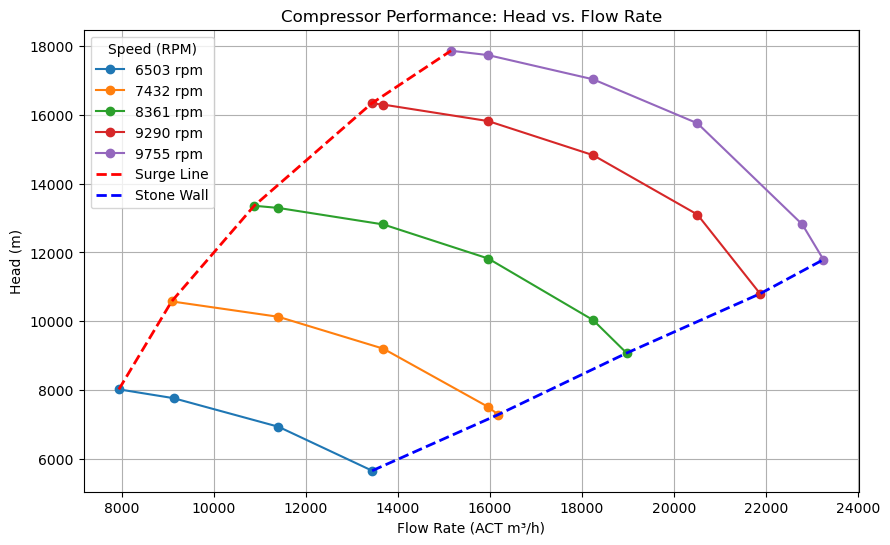

In [10]:
# Extract head and flow values for curves 19 to 23 (case 103)

rpm_values = [6503, 7432, 8361, 9290, 9755]
head_values = []
flow_values_sec = []

for curve_index in range (compressor.Curves.Count-5,compressor.Curves.Count): # curves 19-23
    curve = main_flowsheet.Flowsheets.Item("TPL18").Operations.Item("26KA750").Curves.Item(curve_index)
    
    # Retrieve head and flow values
    head_values.append(curve.HeadValue)    # head in meters
    flow_values_sec.append(curve.GasFlowRateValue) #flow in m3/s   
    
    # Convert flow from m3/s to m3/hr
    flow_values_hr = [[flow * 3600 for flow in curve] for curve in flow_values_sec]
    
# Identify surge line (start points) and stone wall (end points)
surge_points = [(flow_values_hr[i][0], head_values[i][0]) for i in range(len(rpm_values))]
stone_wall_points = [(flow_values_hr[i][-1], head_values[i][-1]) for i in range(len(rpm_values))]

# Plot the extracted data
plt.figure(figsize=(10, 6))
    
for i in range(len(rpm_values)):
    plt.plot(flow_values_hr[i], head_values[i], marker='o', label=f"{rpm_values[i]} rpm")

# Add dashed lines for surge and stone wall
surge_x, surge_y = zip(*surge_points)  # Unpack start points
stone_x, stone_y = zip(*stone_wall_points)  # Unpack end points

plt.plot(surge_x, surge_y, 'r--', linewidth=2, label="Surge Line")  # Dashed red line
plt.plot(stone_x, stone_y, 'b--', linewidth=2, label="Stone Wall")  # Dashed blue line

plt.xlabel("Flow Rate (ACT m³/h)")
plt.ylabel("Head (m)")
plt.title("Compressor Performance: Head vs. Flow Rate")
plt.legend(title="Speed (RPM)")
plt.grid(True)

plt.show()    

__Since the manufacturer’s data sheet plots discharge pressure (barA) vs. standard volume flow (Sm³/h) while UniSim uses head (m) vs. actual volume flow (ACT m³/h), it is important to convert UniSim data to match the manufacturer’s format for a proper comparison.__
***
<div class="alert alert-block alert-info">
<b></b>
 
#### Steps to Convert UniSim Data:
1-Convert Head (m) to Discharge Pressure (barA)
- Assuming polytropic process, here is formula 
<br>
$P_{out}=P_{in}*\left(\frac{H\cdot M{_w}\cdot\left(\frac{\gamma-1}{\gamma}\right)}{Z_{av} \cdot R \cdot T} +1 \right)^{\left(\frac{\gamma}{\gamma-1}\right)}$
<br>
$H=\left(\frac{\gamma}{\gamma -1}\right)\left(\frac{Z_{av}\cdot R\cdot T}{M_w}\right) \left[\left(\frac{P_{out}}{P_{in}}\right)^\left(\frac{\gamma}{\gamma -1}\right) - 1\right]$
<br>
where:
- $P_{out}$ is Discharge pressure (barA)
- $P_{in}$ is Suction pressure (barA)
- $H$ head, picked up from unisim (kJ/kg)
- $Mw$ molecular weight of gas
- $R$ gas universal constant 8.314(J/kg.K)
- $T$ is inlet temperature (K)
- $Z_{av}$ is averaged compressibility factor
- $\gamma$ heat capacity ratio, picked up from unisim
<br>

2-Convert Actual Volume Flow (ACT m³/h) to Standard Volume Flow (Sm³/h)
- Use the gas law transformation:
<br>
$Standard Flow = Actual Flow \times \frac{P_{actual}}{P_{standard}} \times \frac{T_{standard}}{T_{actual}} $
<br>
- Typical standard conditions are: 
<br>
$P_{standard} = 1.01325 barA$
<br>
$T_{standard} = 288.15 K$
- Actual conditions can be retrieved from Unisim. 
<br>
    
Consequently, to start conversion we need:
<br>
a) Select a point from UniSim’s curve at a specific RPM.
<br>
b) Read its head (kJ/kg) and flow rate (ACT m³/h).
<br>
c) Convert head to discharge pressure (barA).
<br>
d) Convert actual flow (ACT m³/h) to standard flow (Sm³/h).
<br>
e) Repeat for multiple points to create a matching curve for comparison.
</div>



In [1]:
# Given data from UniSim (Head in meters, Flow in ACT m³/h)
head_values = [8017.93, 7762.08, 6930.59, 5651.38]  # Example from Curve 
flow_act_m3_hr = [7927.7, 9119.9, 11399.8, 13437.0]  # ACT m³/h (converted from m³/s)

# Compressor gas properties (from UniSim)
P_in = 23.2  # Suction Pressure (barA) - adjust based on your case
T_in = 273+23.7  # Inlet Temperature (K)

#----------Specific Gas Constant (J/kg·K)--------------
# Given values from UniSim
cv_kj_per_kgmol_C = 33.55  # Cv in kJ/kgmol·°C
gamma = 1.309  # Cp/Cv ratio
M = 21.46  # Example molar mass in kg/kmol (change based on gas type)

# Convert Cv from kJ/kgmol·°C to kJ/kg·°C
cv_kj_per_kg_C = cv_kj_per_kgmol_C / M

# Convert Cv to J/kg·K
cv_j_per_kg_K = cv_kj_per_kg_C * 1000

# Calculate Specific Gas Constant (R)
R_gas = (cv_j_per_kg_K * gamma) / (gamma - 1)
#------------------------------------------------------

# Conversion to Discharge Pressure (barA)
P_out_values = [P_in * math.exp((9.81 * H) / (R_gas * T_in)) for H in head_values]

# Conversion to Standard Flow (Sm³/h)
P_standard = 1.01325  # barA (standard conditions)
T_standard = 288.15  # K (standard temperature)

flow_std_m3_hr = [F * (P_in / P_standard) * (T_standard / T_in) for F in flow_act_m3_hr]

# Plot Manufacturer vs. Converted UniSim Data
plt.figure(figsize=(10, 6))

plt.plot(flow_std_m3_hr, P_out_values, marker='o', label="Converted UniSim Data")
# Manufacturer data should be plotted separately if available

plt.xlabel("Standard Flow Rate (Sm³/h)")
plt.ylabel("Discharge Pressure (barA)")
plt.title("Comparison: Manufacturer vs. UniSim Compressor Curves")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'math' is not defined

In [12]:
R_gas

6622.835590863712

In [13]:
print("Available attributes for curve:", dir(curve))

Available attributes for curve: ['ActivateCurve', 'AddRef', 'Application', 'CreateUserVariable', 'DeleteAllData', 'Efficiency', 'EfficiencyValue', 'FlowUnits', 'GasFlowRate', 'GasFlowRateValue', 'GetIDsOfNames', 'GetTypeInfo', 'GetTypeInfoCount', 'GetUserVariable', 'Head', 'HeadUnits', 'HeadValue', 'Invoke', 'IsValid', 'Moniker', 'OpenStorage', 'Parent', 'QueryInterface', 'Release', 'Speed', 'SpeedValue', 'TaggedName', 'TypeName', 'UniqueID', 'VisibleTypeName', '_ApplyTypes_', '_FlagAsMethod', '_LazyAddAttr_', '_NewEnum', '_Release_', '_UpdateWithITypeInfo_', '__AttrToID__', '__LazyMap__', '__bool__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__'

In [14]:
for i in range(compressor.Curves.Count-5,compressor.Curves.Count):
    curve_item = compressor.Curves.Item(i)
    print(f"Curve {i} Head:", curve_item.HeadValue)

Curve 19 Head: (8017.929900628656, 7762.0871225138035, 6930.598096189831, 5651.384208674725)
Curve 20 Head: (10576.357675658865, 10128.632814467734, 9201.202746095762, 7506.24434541867, 7282.381915332962)
Curve 21 Head: (13358.647876695915, 13294.687186755928, 12814.981976515935, 11823.591216164541, 10032.691772419736, 9073.281357038337)
Curve 22 Head: (16332.820167947262, 16300.839817878685, 15821.134607638694, 14829.743847287298, 13102.805106738795, 10800.22010574457)
Curve 23 Head: (17867.876828478635, 17739.955448598655, 17036.387808272957, 15757.173917698705, 12814.981976515935, 11791.610866095965)


In [15]:
for i in range(compressor.Curves.Count-5,compressor.Curves.Count):
    curve_item = compressor.Curves.Item(i)
    print(f"Curve {i} Flow:", curve_item.GasFlowRateValue)

Curve 19 Flow: (2.2035258236111113, 2.533305198611111, 3.1666314972222223, 3.732502925)
Curve 20 Flow: (2.5220627197222223, 3.1666314972222223, 3.799957797222222, 4.433284097222222, 4.4932439833333335)
Curve 21 Flow: (3.020479275, 3.1666314972222223, 3.799957797222222, 4.433284097222222, 5.066610397222222, 5.268975013888889)
Curve 22 Flow: (3.7287554333333337, 3.799957797222222, 4.433284097222222, 5.066610397222222, 5.696189202777777, 6.074685986111111)
Curve 23 Flow: (4.2084345249999995, 4.433284097222222, 5.066610397222222, 5.696189202777777, 6.329515502777777, 6.45693026111111)


In [16]:
#print("Available attributes for flow:", [attr for attr in dir(curve) if "flow" in attr.lower()])
#print("Flow variable:", curve.GasFlowRate)
#print("Flow value:", curve.GasFlowRateValue)

In [17]:
#print("Available attributes for compressor:", [attr for attr in dir(compressor) if "flow" in attr.lower()])
#print("Liquid volume flow:", compressor.LiqVolFlowValue)
#print("Mass flow:", compressor.MassFlowValue)
#print("Molar flow:", compressor.MolarFlowValue)
#print("Sizing mass flow rate:", compressor.SizingMassFlowRateValue)

In [18]:
    "
    import matplotlib.pyplot as plt
import win32com.client


# Launch UniSim
unisim_app = win32com.client.Dispatch("UniSimDesign.Application")
unisim_app.Visible = True

# Open the simulation file
case = unisim_app.SimulationCases.Open(r"C:\Users\sahm\Downloads\1_Sugg\1.usc")


# Access the main flowsheet
main_flowsheet = case.Flowsheet

# Print all available attributes and methods of the flowsheet
#print(dir(main_flowsheet))

# List all subflowsheets using the Flowsheets collection
print("Subflowsheets found in 'Flowsheets':")
for i in range(main_flowsheet.Flowsheets.Count):
    sub = main_flowsheet.Flowsheets.Item(i)
    print(f"{i}: {sub.Name}")
    
    
    tpl18 = main_flowsheet.Flowsheets.Item("TPL18")

print("Operations in TPL18:")
for i in range(tpl18.Operations.Count):
    op = tpl18.Operations.Item(i)
    print(f"{i}: {op.Name}")
    
    
    compressor = tpl18.Operations.Item("26KA750")
#print(dir(compressor))

print("Using performance curves:", compressor.UsingCurves)

# Access the first (and only) curve

curve_data = compressor.Curves.Item(0)
print(dir(curve_data))


for i in range(compressor.Curves.Count-5,compressor.Curves.Count):
    av_prop = compressor.Curves.Item(i)
    print(f"{i}: {av_prop.Name}")
    
    curve = compressor.Curves.Item(19)

print("Speed:", curve.SpeedValue)
print("Flow:", curve.GasFlowRateValue)
print("Head:", curve.HeadValue)
print("Efficiency:", curve.EfficiencyValue)

plt.plot(curve.GasFlowRateValue,curve.HeadValue)

SyntaxError: unterminated string literal (detected at line 1) (3612908858.py, line 1)

In [ ]:
    "
import win32com.client
import matplotlib.pyplot as plt

# Launch UniSim
unisim_app = win32com.client.Dispatch("UniSimDesign.Application")
unisim_app.Visible = True

# Open the simulation file
case = unisim_app.SimulationCases.Open(r"C:\Users\sahm\Downloads\1_Sugg\1.usc")

# Access the main flowsheet
main_flowsheet = case.Flowsheet

# Extract head & flow values for Curves 19 to 23 (6503-9755 rpm)
rpm_values = [6503, 7432, 8361, 9290, 9755]
head_values = []
flow_values_sec = []

for curve_index in range(19, 24):  # Curves 19 to 23
    curve = main_flowsheet.Flowsheets.Item("TPL18").Operations.Item("26KA750").Curves.Item(curve_index)

    # Retrieve head and flow values
    head_values.append(curve.HeadValue)  # Head in meters
    flow_values_sec.append(curve.GasFlowRateValue)  # Flow in m³/s

# Convert flow from m³/s to m³/h
flow_values_hr = [[flow * 3600 for flow in curve] for curve in flow_values_sec]

# Plot the extracted data
plt.figure(figsize=(10, 6))

for i in range(len(rpm_values)):
    plt.plot(flow_values_hr[i], head_values[i], marker='o', label=f"{rpm_values[i]} rpm")

plt.xlabel("Flow Rate (ACT m³/h)")
plt.ylabel("Head (m)")
plt.title("Compressor Performance: Head vs. Flow Rate")
plt.legend(title="Speed (RPM)")
plt.grid(True)

plt.show()

In [ ]:
"""
Spyder Editor

This is a temporary script file.
"""
import win32com.client

class UniSimCompressorData:
    def __init__(self, unisim_path, subflowsheet_tag, compressor_name):
        """Initialize UniSim connection and retrieve data."""
        self.unisim_path = unisim_path
        self.subflowsheet_tag = subflowsheet_tag
        self.compressor_name = compressor_name
        
        # Connect to UniSim
        self.unisim_app = win32com.client.Dispatch("UniSimDesign.Application")
        self.unisim_app.Visible = True
        self.case = self.unisim_app.SimulationCases.Open(self.unisim_path)
        
        # Access the subflowsheet
        self.flowsheet = self.case.Flowsheet.Flowsheets.Item(self.subflowsheet_tag)
        self.compressor = self.flowsheet.Operations.Item(self.compressor_name)

    def get_operations(self):
        """Retrieve all existing operations within the subflowsheet."""
        operations = [op.Name for op in self.flowsheet.Operations]
        return operations

    def get_compressor_head_flow(self):
        """Extract head (m) and flow (ACT m³/h) from compressor curves."""
        head_values = []
        flow_values_sec = []

        for curve_index in range(self.compressor.Curves.Count):
            curve = self.compressor.Curves.Item(curve_index)

            head_values.append(curve.HeadValue)  # Head in meters
            flow_values_sec.append(curve.GasFlowRateValue)  # Flow in ACT m³/s

        # Convert flow from ACT m³/s to ACT m³/h
        flow_values_hr = [[flow * 3600 for flow in curve] for curve in flow_values_sec]

        return head_values, flow_values_hr

    def display_results(self):
        """Display operations, head, and flow."""
        print("\n--- Existing Operations in Subflowsheet ---")
        print(self.get_operations())

        head_values, flow_values_hr = self.get_compressor_head_flow()
        print("\n--- Compressor Head and Flow Data ---")
        for i, (head, flow) in enumerate(zip(head_values, flow_values_hr)):
            print(f"Curve {i}: Head (m) = {head}, Flow (ACT m³/h) = {flow}")

# Example usage:
unisim_path = r"C:\Users\sahm\Downloads\1_Sugg\1.usc"
subflowsheet_tag = "TPL18"
compressor_name = "26KA750"

compressor_data = UniSimCompressorData(unisim_path, subflowsheet_tag, compressor_name)
compressor_data.display_results()
